# Apache Drill as a federated SQL query engine

**Dataset**: HealthData.gov (U.S. Department of Health & Human Services), COVID-19

## Goal

Show that Drill can query heterogeneous sources with a single SQL query and no ETL.

## Sources

| Plugin | Type | Contents |
| --- | --- | --- |
| **`dfs`** | Filesystem (local, or HDFS/S3) | `covid/hospital_capacity.csv`, `covid_parquet/hospital_capacity.parquet`, `county/community_profile.csv`, `treatments/treatments_clean.csv` |
| **`postgre`** | PostgreSQL via JDBC | `estimated_beds` table |
| **`mongo`** | MongoDB | `therapeutic` collection |

## Architecture

Queries run over the REST API (`http://drill:8047/query.json`, inside the `health-net` Docker network). Each run is timed and logged to `timings` for a final summary.

In [1]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

DRILL_REST = "http://drill:8047/query.json"

def drill_query(sql: str, label: str = None, group: str = None):
    """execute a SQL query on Apache Drill and return the result as a pandas DataFrame"""
    payload = {"queryType": "SQL", "query": sql}

    init = time.perf_counter()
    r = requests.post(DRILL_REST, json=payload, timeout=120)
    end = time.perf_counter() - init

    r.raise_for_status()  # raise an exception if the request failed

    data = r.json()

    if data.get("queryState") == "FAILED":
        raise RuntimeError(f"ERROR: {data}")

    df = pd.DataFrame(data.get("rows", []), columns=data.get("columns", []))

    timings.append({"query": label, "group": group, "seconds": end, "rows": len(df)})

    print(f"{label} {end:.3f}s — {len(df)} rows")
    return df

timings = []  # accumulates execution times for every query run in this notebook

# sanity check
drill_query("SELECT * FROM sys.version", label="sanity-check", group="setup")

sanity-check 0.401s — 1 rows


,version,commit_id,commit_message,commit_time,build_email,build_time
0,1.21.0,ff86c29b125776c56f361fc9187fb96458de37a6,[maven-release-plugin] prepare release drill-1...,15.02.2023 @ 05:29:23 UTC,None,None


## Query 1 — Schema-on-read on raw CSV (source: `dfs`, Dataset 1)

COVID hospitalization trend by state and date, read straight from the raw CSV.

Note: `inpatient_beds_used_covid` has comma thousands separators and empty values, cleaned with `REPLACE` + `NULLIF` before `CAST`. The resulting `NULL`s are filtered out afterward, since Drill sorts them first in `ORDER BY ... DESC`.

In [2]:
q1 = """
SELECT state, `date`, covid_beds_used FROM (
  SELECT state,
         `date`,
         SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
  FROM dfs.healthdata.`covid/hospital_capacity.csv`
  WHERE `date` >= '2021/01/01'
  GROUP BY state, `date`
) 
WHERE covid_beds_used IS NOT NULL
ORDER BY covid_beds_used DESC
LIMIT 20
"""
df1 = drill_query(q1, label="Q1 dfs-csv", group="single-source")
df1

Q1 dfs-csv 3.298s — 20 rows


,state,date,covid_beds_used
0,CA,2021/01/14,30334
1,CA,2021/01/06,22872
2,CA,2021/01/07,22835
3,CA,2021/01/05,22715
4,CA,2021/01/10,22678
5,CA,2021/01/08,22636
6,CA,2021/01/11,22594
7,CA,2021/01/09,22564
8,CA,2021/01/12,22453
9,CA,2021/01/04,22445


## Query 2 — Aggregation on PostgreSQL (source: `postgreSQL`, Dataset 2)

Estimated COVID bed occupancy by state. Drill acts as a JDBC client here, pushing part of the aggregation down to PostgreSQL.

In [3]:
q2 = """
SELECT state,
       COUNT(*) AS num_observations,
       ROUND(AVG(estimated_beds_covid), 0)  AS avg_estimated_beds_covid,
       ROUND(AVG(pct_beds_covid), 4)   AS avg_pct_covid
FROM pg.healthdata.estimated_beds
GROUP BY state
ORDER BY avg_estimated_beds_covid DESC
LIMIT 20
"""
df2 = drill_query(q2, label="Q2 postgre", group="single-source")
df2

Q2 postgre 4.803s — 20 rows


,state,num_observations,avg_estimated_beds_covid,avg_pct_covid
0,CW,31,24884.0,3.6145
1,FL,31,4254.0,8.2155
2,TX,31,3146.0,5.4910
3,CA,31,2137.0,3.6074
4,MO,31,1318.0,9.2265
5,GA,31,979.0,5.1148
6,NY,31,803.0,1.6984
7,NV,31,749.0,10.1061
8,OH,31,698.0,2.4335
9,AZ,31,673.0,4.8058


## Query 3 — Schema flexibility on MongoDB (source: `mongo`, Dataset 3)

Active therapy centers by state and drug. MongoDB is a document store — Drill reads the JSON-like documents in the `therapeutic` collection and treats them as SQL rows, with no relational schema declared upfront.

In [4]:
q3 = """
SELECT t.state,
       t.order_label     AS therapy_name,
       COUNT(*)          AS num_centers
FROM mongo.healthdata.therapeutic t
WHERE t.provider_status = 'ACTIVE'
GROUP BY t.state, t.order_label
ORDER BY num_centers DESC
LIMIT 20
"""
df3 = drill_query(q3, label="Q3 mongo", group="single-source")
df3

Q3 mongo 0.415s — 20 rows


,state,therapy_name,num_centers
0,CA,Renal Paxlovid,1642
1,CA,Paxlovid,1512
2,TX,Renal Paxlovid,1072
3,CA,Lagevrio (molnupiravir),852
4,TX,Paxlovid,821
5,FL,Renal Paxlovid,777
6,PA,Renal Paxlovid,764
7,PA,Paxlovid,755
8,NY,Renal Paxlovid,740
9,NY,Paxlovid,651


## Query 4 — Building the federated join

Instead of jumping straight to a 3-way join:

- **Q4a** `dfs`+`postgre`, **Q4b** `dfs`+`mongo`, **Q4c** `postgre`+`mongo` — 2-way joins, pre-aggregated by state
- **Q4d** — all 3 sources together, still pre-aggregated by state
- **Q4f** — `dfs`+`postgre` joined row by row on state + date, enriched with `mongo`'s aggregated therapy-center counts

### Q4a — `dfs` + `pstgreg` (2-way, by state)

In [5]:
q4a = """
SELECT h.state, h.covid_beds_used, e.avg_estimated_beds_covid
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) h
JOIN (
    SELECT state,
           ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
) e ON h.state = e.state
ORDER BY h.covid_beds_used DESC
"""
df4a = drill_query(q4a, label="Q4a dfs+postgre", group="2-way-join")
print(f"Q4a: dfs+postgre length = {len(df4a)} ")
df4a.head(10)


Q4a dfs+postgre 4.195s — 51 rows
Q4a: dfs+postgre length = 51 


,state,covid_beds_used,avg_estimated_beds_covid
0,FL,2868,4254.0
1,TX,2377,3146.0
2,CA,1670,2137.0
3,MO,1250,1318.0
4,NY,743,803.0
5,GA,726,979.0
6,NV,659,749.0
7,AZ,563,673.0
8,OH,551,698.0
9,AR,523,623.0


### Q4b — `dfs` + `mongo` (2-way, by state)

In [6]:
q4b = """
SELECT h.state, h.covid_beds_used, c.num_therapy_centers
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) h
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON h.state = c.state
ORDER BY h.covid_beds_used DESC
"""
df4b = drill_query(q4b, label="Q4b dfs+mongo", group="2-way-join")
print(f"Q4b: dfs+mongo length = {len(df4b)} ")
df4b.head(10)

Q4b dfs+mongo 1.102s — 52 rows
Q4b: dfs+mongo length = 52 


,state,covid_beds_used,num_therapy_centers
0,FL,2868,1884
1,TX,2377,2481
2,CA,1670,4007
3,MO,1250,510
4,NY,743,1796
5,GA,726,784
6,NV,659,278
7,AZ,563,620
8,OH,551,1198
9,AR,523,61


### Q4c — `postgre` + `mongo` (2-way, by state)

In [7]:
q4c = """
SELECT e.state, e.avg_estimated_beds_covid, c.num_therapy_centers
FROM (
    SELECT state,
           ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
) e
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON e.state = c.state
ORDER BY e.avg_estimated_beds_covid DESC
"""
df4c = drill_query(q4c, label="Q4c postgre+mongo", group="2-way-join")
print(f"Q4c: postgre+mongo length = {len(df4c)} ")
df4c.head(10)

Q4c postgre+mongo 2.620s — 51 rows
Q4c: postgre+mongo length = 51 


,state,avg_estimated_beds_covid,num_therapy_centers
0,FL,4254.0,1884
1,TX,3146.0,2481
2,CA,2137.0,4007
3,MO,1318.0,510
4,GA,979.0,784
5,NY,803.0,1796
6,NV,749.0,278
7,OH,698.0,1198
8,AZ,673.0,620
9,AR,623.0,61


### Q4d — `dfs` + `postgre` + `mongo` (3-way, by state)

In [8]:
q4d = """
SELECT
    h.state,
    h.covid_beds_used,
    e.avg_estimated_beds_covid,
    c.num_therapy_centers
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) h
JOIN (
    SELECT state,
           ROUND(AVG(estimated_beds_covid), 0) AS avg_estimated_beds_covid
    FROM pg.healthdata.estimated_beds
    GROUP BY state
) e ON h.state = e.state
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON h.state = c.state
ORDER BY h.covid_beds_used DESC
"""
df4d = drill_query(q4d, label="Q4d dfs+postgre+mongo", group="3-way-join")
print(f"Q4d: dfs+postgre+mongo length = {len(df4d)} ")
df4d.head(15)

Q4d dfs+postgre+mongo 1.953s — 51 rows
Q4d: dfs+postgre+mongo length = 51 


,state,covid_beds_used,avg_estimated_beds_covid,num_therapy_centers
0,FL,2868,4254.0,1884
1,TX,2377,3146.0,2481
2,CA,1670,2137.0,4007
3,MO,1250,1318.0,510
4,NY,743,803.0,1796
5,GA,726,979.0,784
6,NV,659,749.0,278
7,AZ,563,673.0,620
8,OH,551,698.0,1198
9,AR,523,623.0,61


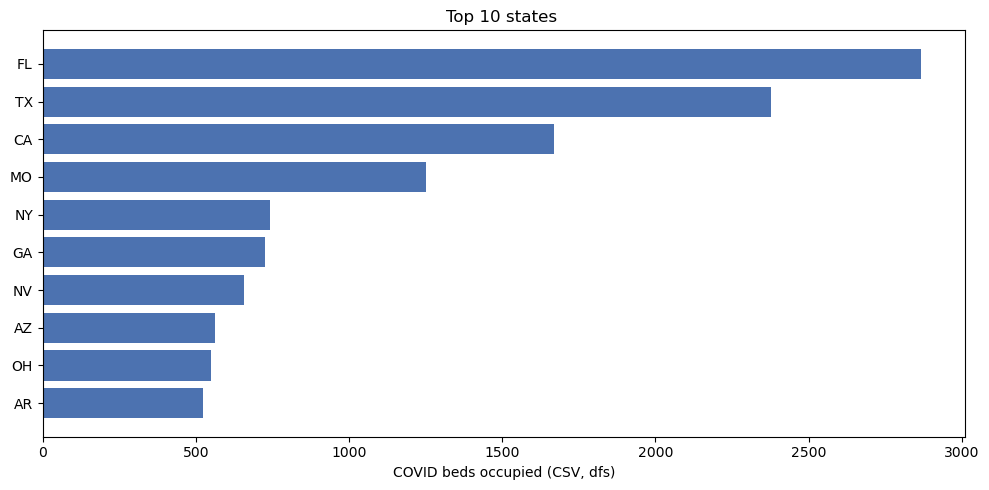

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
top = df4d.head(10).sort_values("covid_beds_used")
ax.barh(top["state"], top["covid_beds_used"], color="#4C72B0")
ax.set_xlabel("COVID beds occupied (CSV, dfs)")
ax.set_title("Top 10 states ")
plt.tight_layout()
plt.show()

### Q4f — `dfs` + `postgre` + `mongo`, row-level join

The heaviest query in the demo: real hospital data (CSV) and estimated beds (PostgreSQL) joined row by row on state + date, enriched with `mongo`'s aggregated therapy-center counts per state — fine-grained on two sources, coarse-grained on the third.

In [10]:
q4f = """
SELECT hp.state, hp.`date`, hp.covid_beds_used, hp.estimated_beds_covid, c.num_therapy_centers
FROM (
    SELECT h.state, h.`date`,
           CAST(NULLIF(REPLACE(h.inpatient_beds_used_covid, ',', ''), '') AS BIGINT) AS covid_beds_used,
           e.estimated_beds_covid
    FROM dfs.healthdata.`covid/hospital_capacity.csv` h
    JOIN pg.healthdata.estimated_beds e
      ON h.state = e.state
     AND TO_DATE(h.`date`, 'yyyy/MM/dd') = e.collection_date
) hp
JOIN (
    SELECT t.state,
           COUNT(*) AS num_therapy_centers
    FROM mongo.healthdata.therapeutic t
    WHERE t.provider_status = 'ACTIVE'
    GROUP BY t.state
) c ON hp.state = c.state
ORDER BY hp.state, hp.`date`
"""
df4f = drill_query(q4f, label="Q4f dfs+postgre+mongo row-level", group="row-level-join")
df4f.head(10)

Q4f dfs+postgre+mongo row-level 3.363s — 1581 rows


,state,date,covid_beds_used,estimated_beds_covid,num_therapy_centers
0,AK,2021/06/28,15,15.0,49
1,AK,2021/06/29,14,14.0,49
2,AK,2021/06/30,18,17.0,49
3,AK,2021/07/01,19,18.0,49
4,AK,2021/07/02,23,22.0,49
5,AK,2021/07/03,22,21.0,49
6,AK,2021/07/04,24,23.0,49
7,AK,2021/07/05,27,27.0,49
8,AK,2021/07/06,21,21.0,49
9,AK,2021/07/07,30,29.0,49


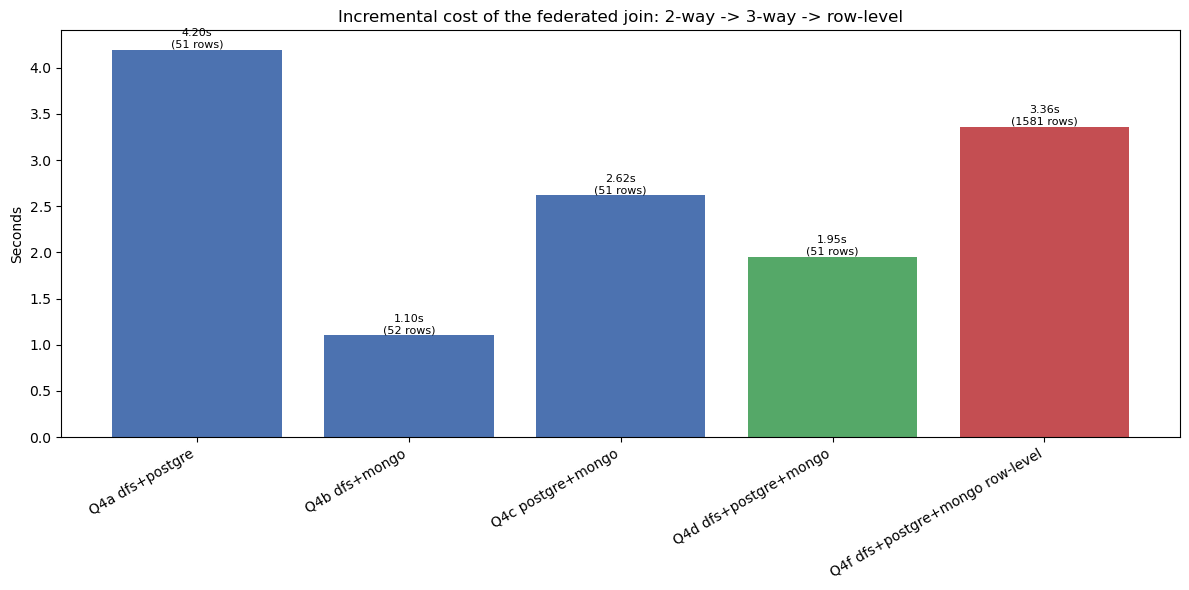

In [11]:
# Incremental cost: execution time as join complexity grows
join_steps = ["Q4a dfs+postgre", "Q4b dfs+mongo", "Q4c postgre+mongo", "Q4d dfs+postgre+mongo",
              "Q4f dfs+postgre+mongo row-level"]
df_join_steps = pd.DataFrame(timings)
df_join_steps = df_join_steps[df_join_steps["query"].isin(join_steps)].set_index("query").loc[join_steps]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4C72B0"] * 3 + ["#55A868"] + ["#C44E52"]
ax.bar(df_join_steps.index, df_join_steps["seconds"], color=colors)
ax.set_ylabel("Seconds")
ax.set_title("Incremental cost of the federated join: 2-way -> 3-way -> row-level")
for i, (v, r) in enumerate(zip(df_join_steps["seconds"], df_join_steps["rows"])):
    ax.text(i, v, f"{v:.2f}s\n({r} rows)", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Query 6 — Multi-scale: state + county on the same `dfs` plugin (Dataset 1 + 4)

Two different CSVs, different granularity (state vs. county), same storage plugin. Shows Drill's federation also works across different files within the same source.

In [12]:
q6 = """
SELECT s.state,
       s.covid_beds_used   AS state_covid_beds,
       c.county,
       c.cases_last_7_days AS county_cases_7d
FROM (
    SELECT state,
           SUM(CAST(NULLIF(REPLACE(inpatient_beds_used_covid, ',', ''), '') AS BIGINT)) AS covid_beds_used
    FROM dfs.healthdata.`covid/hospital_capacity.csv`
    WHERE `date` = '2021/07/09'
    GROUP BY state
) s
JOIN dfs.healthdata.`county/community_profile.csv` c
  ON s.state = c.state
ORDER BY state_covid_beds DESC, county_cases_7d DESC
LIMIT 30
"""
df6 = drill_query(q6, label="Q6 dfs-multi-scale", group="other")
df6

Q6 dfs-multi-scale 1.104s — 30 rows


,state,state_covid_beds,county,county_cases_7d
0,FL,2868,"Volusia County, FL",99
1,FL,2868,"St. Lucie County, FL",90
2,FL,2868,"Wakulla County, FL",9
3,FL,2868,"Osceola County, FL",87
4,FL,2868,"Martin County, FL",85
5,FL,2868,"Collier County, FL",83
6,FL,2868,"Leon County, FL",82
7,FL,2868,"Marion County, FL",82
8,FL,2868,"Putnam County, FL",8
9,FL,2868,"Suwannee County, FL",8


## Summary: execution times by category

Every query run in this notebook, timed via the REST API and grouped by category (single source, 2-way join, 3-way join, row-level join) — useful for discussing what drives latency in a federated engine: number of sources involved, pre-aggregation vs. row-level joins.

In [13]:
df_timings = pd.DataFrame(timings)
df_timings

,query,group,seconds,rows
0,sanity-check,setup,0.401040,1
1,Q1 dfs-csv,single-source,3.297910,20
2,Q2 postgre,single-source,4.802987,20
3,Q3 mongo,single-source,0.415435,20
4,Q4a dfs+postgre,2-way-join,4.195352,51
5,Q4b dfs+mongo,2-way-join,1.101967,52
6,Q4c postgre+mongo,2-way-join,2.619943,51
7,Q4d dfs+postgre+mongo,3-way-join,1.952526,51
8,Q4f dfs+postgre+mongo row-level,row-level-join,3.363280,1581
9,Q6 dfs-multi-scale,other,1.104160,30


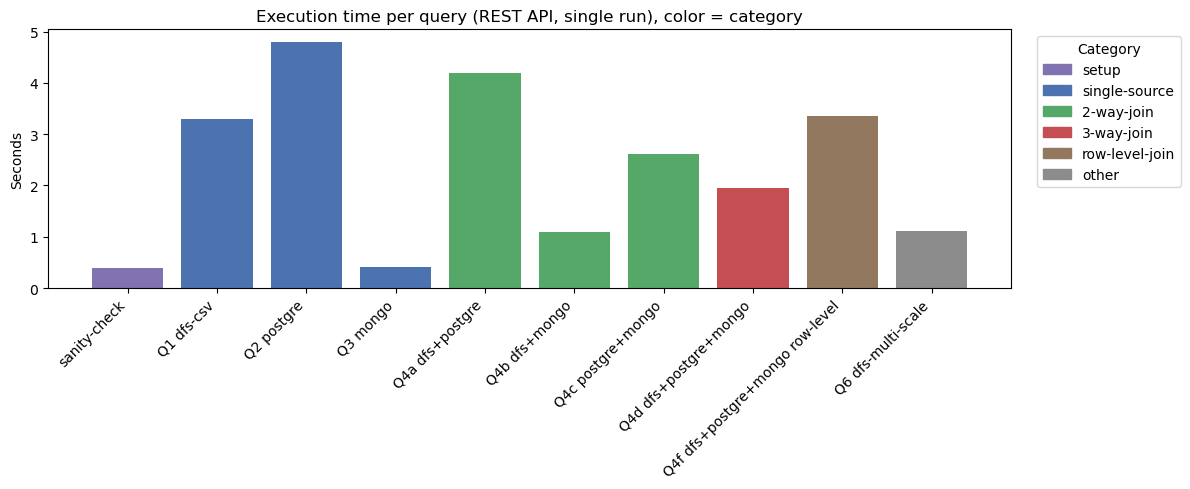

In [14]:
group_colors = {
    "setup": "#8172B2",
    "single-source": "#4C72B0",
    "2-way-join": "#55A868",
    "3-way-join": "#C44E52",
    "row-level-join": "#937860",
    "other": "#8C8C8C",
}
colors = df_timings["group"].map(group_colors)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_timings["query"], df_timings["seconds"], color=colors)
ax.set_ylabel("Seconds")
ax.set_title("Execution time per query (REST API, single run), color = category")
plt.xticks(rotation=45, ha="right")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Conclusions

- Drill queried raw CSV, PostgreSQL, and MongoDB directly, with no ETL, through a single SQL/REST endpoint.
- Building the federated join incrementally (Q4a → Q4f) shows cost grows both with the number of sources (2-way → 3-way) and, more sharply, when moving from a pre-aggregated join to a row-level join on a composite key: less work happens near the data, more falls on Drill in memory.
- Schema-on-read lets you query "dirty" data (comma-separated numbers, empty values) without cleaning and loading it elsewhere first — the cleanup happens in the query itself, via `REPLACE`/`CAST`.